 # Cognitive Decline & Brain Volume — Exploratory Analysis
 Dataset: OASIS Longitudinal (373 MRI visits, 150 subjects, ages 60-96)
 Source: https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers

 Columns: Subject ID, MRI ID, Group (Demented/Nondemented/Converted), Visit,
 MR Delay, M/F, Hand, Age, EDUC, SES, MMSE, CDR, eTIV, nWBV, ASF

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

 ## 1. Load and inspect

In [ ]:
df = pd.read_csv("oasis_longitudinal.csv")
print(df.shape)
df.head()

(373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [ ]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    str    
 1   MRI ID      373 non-null    str    
 2   Group       373 non-null    str    
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    str    
 6   Hand        373 non-null    str    
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), str(5)
memory usage: 43.8 KB


Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

 ## 2. Clean
 SES and MMSE have a handful of missing values in the real dataset — decide here
 whether to drop or impute (median imputation is a defensible default for SES).

In [ ]:
df["SES"] = df["SES"].fillna(df["SES"].median())
df = df.dropna(subset=["MMSE"])
print("Remaining rows:", len(df))

Remaining rows: 371


 ## 3. Group comparison: Demented vs Nondemented
 This is the core research question: which variables differ most between the two
 groups, and how strongly?

In [ ]:
group_summary = df.groupby("Group")[["Age", "MMSE", "eTIV", "nWBV", "ASF", "EDUC"]].agg(
    ["mean", "std", "count"]
)
group_summary

Age                       MMSE                  \
                  mean       std count       mean       std count   
Group                                                               
Converted    79.756757  7.425203    37  28.675676  1.564432    37   
Demented     76.263889  6.987487   144  24.513889  4.497064   144   
Nondemented  77.057895  8.096104   190  29.226316  0.882722   190   

                    eTIV                        nWBV                  \
                    mean         std count      mean       std count   
Group                                                                  
Converted    1459.270270  135.432773    37  0.723730  0.035430    37   
Demented     1490.319444  170.730502   144  0.716007  0.032040   144   
Nondemented  1495.500000  184.888262   190  0.740900  0.037705   190   

                  ASF                       EDUC                  
                 mean       std count       mean       std count  
Group                                                             
Converted    1.212405  0.109295    37  15.459459  2.523166    37  
Demented     1.192569  0.133069   144  13.694444  2.911943   144  
Nondemented  1.191063  0.144029   190  15.142105  2.742149   190

In [ ]:
demented = df[df["Group"] == "Demented"]
nondemented = df[df["Group"] == "Nondemented"]

for col in ["MMSE", "nWBV", "Age", "EDUC"]:
    t_stat, p_val = stats.ttest_ind(
        demented[col].dropna(), nondemented[col].dropna(), equal_var=False
    )
    print(f"{col}: t={t_stat:.2f}, p={p_val:.4f}")

MMSE: t=-12.40, p=0.0000
nWBV: t=-6.51, p=0.0000
Age: t=-0.96, p=0.3378
EDUC: t=-4.61, p=0.0000


 ## 4. Visualize the group differences

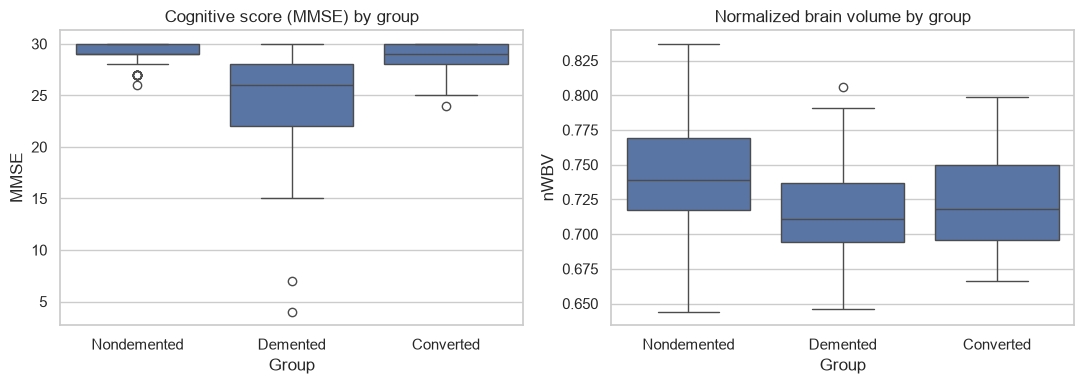

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="Group", y="MMSE", ax=axes[0])
axes[0].set_title("Cognitive score (MMSE) by group")
sns.boxplot(data=df, x="Group", y="nWBV", ax=axes[1])
axes[1].set_title("Normalized brain volume by group")
plt.tight_layout()
plt.savefig("group_comparison.png", dpi=150)
plt.show()

 ## 5. Correlation structure
 Which variables move together? nWBV (brain volume) vs MMSE (cognition) vs Age
 is the classic relationship to check here.

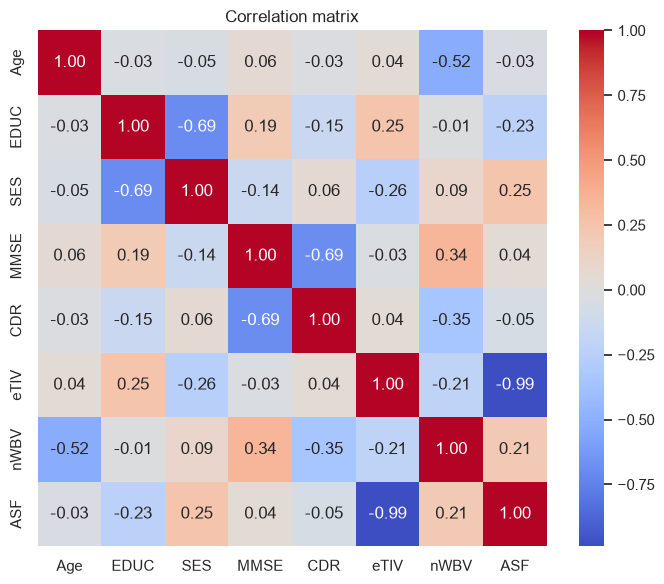

In [ ]:
corr_cols = ["Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

 ## 6. Does education buffer cognitive decline?
 A common finding in this literature is "cognitive reserve" — more years of
 education is associated with better MMSE scores even at a similar brain volume.
 Check whether that shows up here.

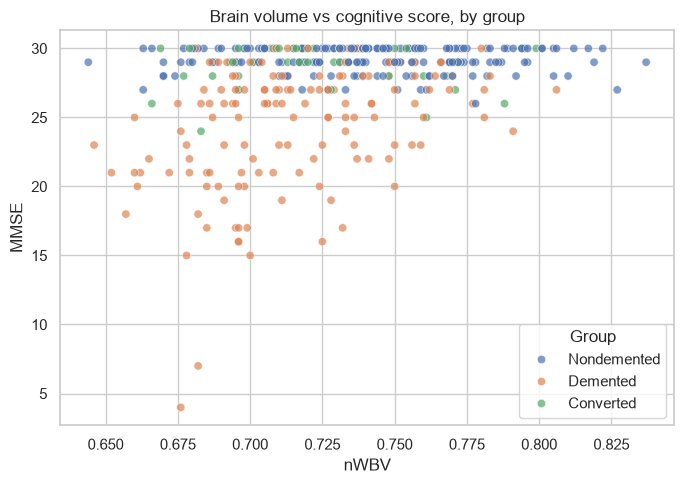

EDUC vs MMSE correlation: r=0.19, p=0.0002


In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="nWBV", y="MMSE", hue="Group", alpha=0.7)
plt.title("Brain volume vs cognitive score, by group")
plt.tight_layout()
plt.savefig("volume_vs_mmse.png", dpi=150)
plt.show()

educ_corr, educ_p = stats.pearsonr(df["EDUC"], df["MMSE"])
print(f"EDUC vs MMSE correlation: r={educ_corr:.2f}, p={educ_p:.4f}")

 ## 7. Write-up (fill this in after running)

 After running the cells above, replace the placeholders below with your actual
 numbers, then this section becomes the case-study text for your portfolio.

 - Sample size after cleaning: ___ visits from ___ subjects
 - MMSE difference between Demented and Nondemented groups: mean difference of ___
   points (p = ___)
 - Brain volume (nWBV) difference between groups: ___ (p = ___)
 - Strongest correlation in the heatmap: ___ and ___ (r = ___)
 - Education vs MMSE: r = ___, p = ___ — does this support or complicate the
   "cognitive reserve" idea?
 - One sentence on what surprised you or what you'd want to check next.